## Setup: Import Libraries and Load Data


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [11]:

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [12]:
# Load the merged master dataset
DATA_PATH = Path('../data/merged/master_student_data.csv')
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())

Dataset loaded: 32548 rows × 19 columns

Column names and types:
code_module                       str
code_presentation                 str
id_student                      int64
gender                            str
region                            str
highest_education                 str
imd_band                          str
age_band                          str
num_of_prev_attempts            int64
studied_credits                 int64
disability                        str
final_result                      str
date_registration             float64
date_unregistration           float64
total_clicks                  float64
num_sites                     float64
module_presentation_length      int64
tma_cma_weighted_score        float64
is_withdrawn                    int64
dtype: object

First few rows:
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013

In [13]:
# Basic dataset information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nTarget variable (final_result) distribution:")
print(df['final_result'].value_counts())
print(f"\nWithdrawal flag distribution:")
print(df['is_withdrawn'].value_counts())

DATASET OVERVIEW

Shape: (32548, 19)

Missing values:
code_module                       0
code_presentation                 0
id_student                        0
gender                            0
region                            0
highest_education                 0
imd_band                          0
age_band                          0
num_of_prev_attempts              0
studied_credits                   0
disability                        0
final_result                      0
date_registration                 0
date_unregistration           22515
total_clicks                      0
num_sites                         0
module_presentation_length        0
tma_cma_weighted_score            0
is_withdrawn                      0
dtype: int64

Target variable (final_result) distribution:
final_result
Pass           12360
Withdrawn      10117
Fail            7047
Distinction     3024
Name: count, dtype: int64

Withdrawal flag distribution:
is_withdrawn
0    22515
1    10033
Name: count, d

## 1. Correlation Matrix Analysis

Identify numeric features and their correlation with target variables (final_result, is_withdrawn). Features with near-zero correlation may have limited predictive power.


In [14]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)

# Prepare data for correlation analysis
df_numeric = df[numeric_cols].copy()

# Convert final_result to numeric for correlation (if categorical)
if not pd.api.types.is_numeric_dtype(df['final_result']):
    # Map final_result to numeric values
    result_mapping = {result: idx for idx, result in enumerate(sorted(df['final_result'].unique()))}
    df_numeric['final_result'] = df['final_result'].map(result_mapping).astype(float)
    print(f"\nFinal result mapping: {result_mapping}")
else:
    df_numeric['final_result'] = df['final_result'].astype(float)

# Ensure all columns are numeric
df_numeric = df_numeric.astype(float)
print(f"\nDataframe for correlation: {df_numeric.shape}")
print(f"Data types: {df_numeric.dtypes.unique()}")

Numeric columns (10):
['id_student', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'date_unregistration', 'total_clicks', 'num_sites', 'module_presentation_length', 'tma_cma_weighted_score', 'is_withdrawn']

Final result mapping: {'Distinction': 0, 'Fail': 1, 'Pass': 2, 'Withdrawn': 3}

Dataframe for correlation: (32548, 11)
Data types: [dtype('float64')]


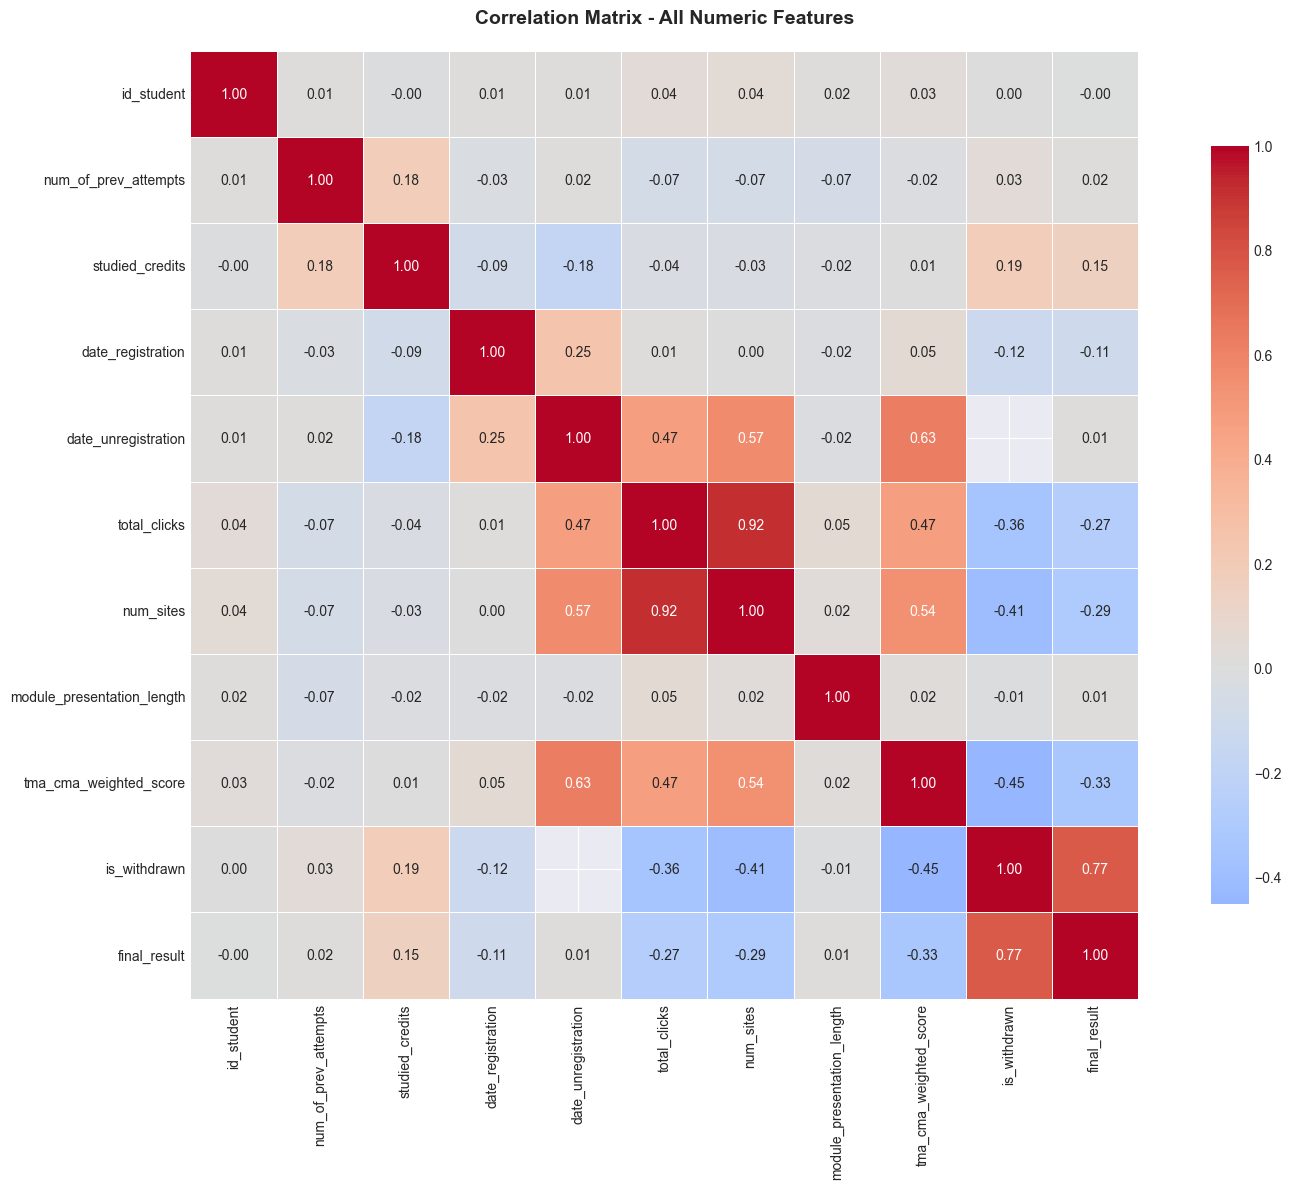

Heatmap generated successfully


In [15]:
# Calculate correlation matrix
correlation_matrix = df_numeric.corr()

# Create heatmap
fig, axes = plt.subplots(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes
)
plt.title('Correlation Matrix - All Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Heatmap generated successfully")

In [16]:
# Analyze correlation with target variables
print("="*80)
print("CORRELATION WITH TARGET VARIABLES")
print("="*80)

# Correlation with final_result
print("\n1. Correlation with final_result (higher = stronger relationship):")
final_result_corr = correlation_matrix['final_result'].sort_values(ascending=False)
print(final_result_corr)

# Correlation with is_withdrawn
print("\n2. Correlation with is_withdrawn (higher = stronger relationship):")
withdrawn_corr = correlation_matrix['is_withdrawn'].sort_values(ascending=False)
print(withdrawn_corr)

# Identify features with near-zero correlation
print("\n3. Features with LOW correlation to final_result (|r| < 0.1):")
low_corr_result = final_result_corr[abs(final_result_corr) < 0.1]
print(low_corr_result)

print("\n4. Features with LOW correlation to is_withdrawn (|r| < 0.1):")
low_corr_withdrawn = withdrawn_corr[abs(withdrawn_corr) < 0.1]
print(low_corr_withdrawn)

CORRELATION WITH TARGET VARIABLES

1. Correlation with final_result (higher = stronger relationship):
final_result                  1.000000
is_withdrawn                  0.770803
studied_credits               0.151606
num_of_prev_attempts          0.016694
module_presentation_length    0.013319
date_unregistration           0.012075
id_student                   -0.002505
date_registration            -0.106130
total_clicks                 -0.267566
num_sites                    -0.294937
tma_cma_weighted_score       -0.333806
Name: final_result, dtype: float64

2. Correlation with is_withdrawn (higher = stronger relationship):
is_withdrawn                  1.000000
final_result                  0.770803
studied_credits               0.188214
num_of_prev_attempts          0.033331
id_student                    0.002986
module_presentation_length   -0.009122
date_registration            -0.123455
total_clicks                 -0.355137
num_sites                    -0.410740
tma_cma_weighte

## 2. Distribution & Outlier Analysis

Create boxplots for key numeric features grouped by final_result to identify outliers and determine appropriate scaling strategy (RobustScaler for outliers vs StandardScaler).


In [17]:
# Key features to analyze
features_to_analyze = ['total_clicks', 'tma_cma_weighted_score', 'studied_credits']
features_present = [col for col in features_to_analyze if col in df.columns]

print(f"Features to analyze: {features_present}")
print(f"\nBasic statistics for key features:")
print(df[features_present].describe())

Features to analyze: ['total_clicks', 'tma_cma_weighted_score', 'studied_credits']

Basic statistics for key features:
       total_clicks  tma_cma_weighted_score  studied_credits
count  32548.000000            32548.000000     32548.000000
mean    1216.755285               50.891978        79.714422
std     1693.205934               34.638101        41.046179
min        0.000000                0.000000        30.000000
25%      144.000000                0.000000        60.000000
50%      603.000000               64.250000        60.000000
75%     1587.000000               79.060033       120.000000
max    24139.000000              100.000000       655.000000


In [ ]:
# Create boxplots grouped by final_result
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(features_present):
    sns.boxplot(
        data=df,
        x='final_result',
        y=feature,
        ax=axes[idx],
        palette='Set2'
    )
    axes[idx].set_title(f'{feature} by Final Result', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Final Result', fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Rotate x labels if needed
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Boxplots generated successfully")

In [ ]:
# Detailed outlier analysis
print("="*80)
print("OUTLIER ANALYSIS FOR SCALING STRATEGY SELECTION")
print("="*80)

for feature in features_present:
    print(f"\n{feature}:")
    
    # Calculate IQR-based outliers
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {len(outliers)} ({outlier_pct:.2f}%)")
    print(f"  Skewness: {df[feature].skew():.3f}")
    print(f"  Kurtosis: {df[feature].kurtosis():.3f}")
    
    if outlier_pct > 5:
        print(f"  ⚠ Recommendation: Use RobustScaler (significant outliers)")
    else:
        print(f"  ✓ Recommendation: StandardScaler is acceptable")

## 3. Target Variable Analysis

Visualize the distribution of final_result to understand class imbalance, which is critical for model selection and evaluation strategy.


In [ ]:
# Final result distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
result_counts = df['final_result'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a']

axes[0].bar(result_counts.index, result_counts.values, color=colors[:len(result_counts)], edgecolor='black')
axes[0].set_title('Distribution of Final Result (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Final Result', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(result_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
result_pct = (result_counts / len(df)) * 100
axes[1].pie(
    result_counts.values,
    labels=[f"{result}\n({pct:.1f}%)" for result, pct in zip(result_counts.index, result_pct.values)],
    colors=colors[:len(result_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)
axes[1].set_title('Distribution of Final Result (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Target distribution plots generated successfully")

In [ ]:
# Detailed target analysis
print("="*80)
print("TARGET VARIABLE ANALYSIS - CLASS IMBALANCE")
print("="*80)

print("\nFinal Result Distribution:")
for result, count in result_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {result}: {count:,} ({pct:.2f}%)")

# Calculate imbalance ratio
max_class = result_counts.max()
min_class = result_counts.min()
imbalance_ratio = max_class / min_class

print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("⚠ HIGH CLASS IMBALANCE DETECTED")
    print("  Recommendation: Consider stratified sampling, class weights, or SMOTE for modeling")
elif imbalance_ratio > 1.5:
    print("⚠ MODERATE CLASS IMBALANCE DETECTED")
    print("  Recommendation: Monitor metrics carefully; use stratified cross-validation")
else:
    print("✓ BALANCED CLASSES")
    print("  Recommendation: Standard training approaches should work well")

## 4. Categorical Impact Analysis

Analyze how categorical features (highest_education, imd_band) influence final_result outcomes.


In [ ]:
# Check available categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Focus on highest_education and imd_band
focus_categorical = ['highest_education', 'imd_band']
focus_cols_present = [col for col in focus_categorical if col in df.columns]

print(f"\nFocusing on: {focus_cols_present}")

for col in focus_cols_present:
    print(f"\n{col} - Unique values ({df[col].nunique()}):")
    print(df[col].value_counts())

In [ ]:
# Create countplots for highest_education
if 'highest_education' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Education levels and their counts
    education_counts = df['highest_education'].value_counts()
    axes[0].barh(education_counts.index, education_counts.values, color='steelblue', edgecolor='black')
    axes[0].set_title('Student Distribution by Highest Education Level', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count', fontsize=11)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(education_counts.values):
        axes[0].text(v + 100, i, str(v), va='center', fontweight='bold')
    
    # Plot 2: Education level vs Final Result (stacked bar)
    education_result = pd.crosstab(df['highest_education'], df['final_result'])
    education_result.plot(kind='bar', ax=axes[1], stacked=False, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a'])
    axes[1].set_title('Final Result Distribution by Highest Education Level', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Highest Education', fontsize=11)
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].legend(title='Final Result', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Highest education plots generated")

In [ ]:
# Create countplots for IMD band
if 'imd_band' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: IMD bands and their counts
    imd_counts = df['imd_band'].value_counts()
    axes[0].barh(imd_counts.index, imd_counts.values, color='coral', edgecolor='black')
    axes[0].set_title('Student Distribution by IMD Band', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Count', fontsize=11)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(imd_counts.values):
        axes[0].text(v + 100, i, str(v), va='center', fontweight='bold')
    
    # Plot 2: IMD band vs Final Result (stacked bar)
    imd_result = pd.crosstab(df['imd_band'], df['final_result'])
    imd_result.plot(kind='bar', ax=axes[1], stacked=False, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a'])
    axes[1].set_title('Final Result Distribution by IMD Band', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('IMD Band', fontsize=11)
    axes[1].set_ylabel('Count', fontsize=11)
    axes[1].legend(title='Final Result', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("IMD band plots generated")

In [ ]:
# Detailed categorical analysis
print("="*80)
print("CATEGORICAL FEATURES IMPACT ON OUTCOMES")
print("="*80)

if 'highest_education' in df.columns:
    print("\n1. HIGHEST EDUCATION LEVEL:")
    education_result = pd.crosstab(df['highest_education'], df['final_result'], margins=True)
    print(education_result)
    
    # Calculate success rate by education
    print("\nSuccess Rates (Pass/Distinction) by Education Level:")
    for edu in df['highest_education'].unique():
        edu_df = df[df['highest_education'] == edu]
        success_count = edu_df[edu_df['final_result'].isin(['Pass', 'Distinction'])].shape[0]
        success_rate = (success_count / len(edu_df)) * 100
        print(f"  {edu}: {success_rate:.1f}% ({success_count}/{len(edu_df)})")

if 'imd_band' in df.columns:
    print("\n2. IMD BAND (Index of Multiple Deprivation):")
    imd_result = pd.crosstab(df['imd_band'], df['final_result'], margins=True)
    print(imd_result)
    
    # Calculate success rate by IMD band
    print("\nSuccess Rates (Pass/Distinction) by IMD Band:")
    for imd in sorted(df['imd_band'].unique()):
        imd_df = df[df['imd_band'] == imd]
        success_count = imd_df[imd_df['final_result'].isin(['Pass', 'Distinction'])].shape[0]
        success_rate = (success_count / len(imd_df)) * 100
        print(f"  {imd}: {success_rate:.1f}% ({success_count}/{len(imd_df)})")

## Summary & Recommendations for Modeling

Key findings from EDA analysis


In [ ]:
print("="*80)
print("EDA SUMMARY & MODELING RECOMMENDATIONS")
print("="*80)

print("\n1. DATA QUALITY:")
print(f"   - Total records: {df.shape[0]:,}")
print(f"   - Total features: {df.shape[1]}")
print(f"   - Missing values: {df.isnull().sum().sum()}")

print("\n2. SCALING STRATEGY:")
outlier_features = []
for feature in features_present:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    if (len(outliers) / len(df)) > 0.05:
        outlier_features.append(feature)

if outlier_features:
    print(f"   ⚠ Use RobustScaler for features with outliers: {outlier_features}")
else:
    print(f"   ✓ StandardScaler acceptable for all numeric features")

print("\n3. CLASS BALANCE:")
if imbalance_ratio > 3:
    print(f"   ⚠ HIGH IMBALANCE ({imbalance_ratio:.1f}:1) - Use stratified sampling")
elif imbalance_ratio > 1.5:
    print(f"   ⚠ MODERATE IMBALANCE ({imbalance_ratio:.1f}:1) - Use class weights")
else:
    print(f"   ✓ Balanced classes ({imbalance_ratio:.1f}:1)")

print("\n4. FEATURE CORRELATION:")
strong_corr = final_result_corr[abs(final_result_corr) > 0.3].drop('final_result')
print(f"   Strong predictors of final_result (|r| > 0.3): {strong_corr.index.tolist()}")

print("\n5. CATEGORICAL INSIGHTS:")
print(f"   - Education level shows impact on success rates")
print(f"   - IMD band (socioeconomic factor) affects outcomes")
print(f"   - Consider interaction features between these categorical variables")

print("\n6. MODEL SELECTION SUGGESTIONS:")
print("   - Use stratified k-fold cross-validation")
print("   - Consider gradient boosting (handles non-linear relationships, outliers)")
print("   - Evaluate on F1 or weighted precision/recall (due to class imbalance)")
print("   - Include feature engineering: interaction terms, polynomial features")
print("\n" + "="*80)